## Actionability analysis: Edge- and Node level actionability of individual nodes.

#### Compute Node- and Edge- level actionability per node

In [6]:
from tools.actionability_ceg import actionability_per_node

In [8]:
# Define directories using pathlib.Path for cross-platform compatibility
str_targets_dir = "./datasets/targets/"         # Directory in which model txt files are stored
str_summary_dir = "./Ground_truth/structural_driver_summary_csv/" # Directory in which model summary (node information) files are stored
str_store_dir = "./actionability_summary/"      # Directory to which actionability computation results are stored
process_type = "Both"                           # Edge- and Node- level actionability are computed

actionability_per_node(str_targets_dir, str_summary_dir, str_store_dir, process_type)

Found 41 text files in datasets\targets

  - A thaliana cell type determination root stem cell niche gene regulatory network kadelka.txt
  - Asymmetric Cell Division in Caulobacter Crescentus A ginsim.txt
  - Asymmetric Cell Division in Caulobacter Crescentus B ginsim.txt
  - Aurora Kinase A in Neuroblastoma.txt
  - B cell differentiation.txt
  - Budding Yeast Cell Cycle.txt
  - C. elegans early embryonic cell cycles kadelka.txt
  - Cardiac development.txt
  - CD4+ T Cell Differentiation and Plasticity.txt
  - Cell Cycle Transcription by Coupled CDK and Network Oscillators.txt
  - Cell-fate decision reduced kadelka.txt
  - Control of proliferation by oncogenes and tumor suppressors ginsim.txt
  - Cortical Area Development.txt
  - Epithelial-to-mesenchymal transition kadelka.txt
  - FGF pathway of Drosophila Signalling Pathways.txt
  - Human Gonadal Sex Determination.txt
  - Immune Surveillance Tumor Immunity and Cancer kadelka.txt
  - Iron acquisition and oxidative stress response in a

#### Aggregate all models actionability data

In [1]:
from tools.actionability_ceg import aggregate_actionability_summary

str_source_dir = "./actionability_summary/Both/" 

#df_actionability_all = aggregate_actionability_summary(str_source_dir)
df_actionability_all = aggregate_actionability_summary(str_source_dir)

Found 41 text files in actionability_summary\Both

Aggregated 41 files. Total rows: 1140


In [2]:
df_actionability_all.head()

,source_file,node_id,node_name,driver_node,node_role,condition_state,IG_nodes,IG_edges,E_redundant,E_ON,E_OFF,edge_actionability,N_OFF,N_ON,node_actionability
0,actionability_summary\Both\A thaliana cell typ...,0,PLT,non-driver,inner node,0,9,19,0,0,0,1.0000,0,0,1.000
1,actionability_summary\Both\A thaliana cell typ...,0,PLT,non-driver,inner node,1,9,19,0,0,0,1.0000,0,0,1.000
2,actionability_summary\Both\A thaliana cell typ...,1,AUXINS,driver,input node,0,9,19,4,1,5,0.4737,3,1,0.500
3,actionability_summary\Both\A thaliana cell typ...,1,AUXINS,driver,input node,1,9,19,0,4,1,0.7368,1,2,0.625
4,actionability_summary\Both\A thaliana cell typ...,2,IAA,non-driver,inner node,0,9,19,0,2,1,0.8421,0,2,0.750


#### Aggregate all models combined actionability data

In [2]:
from tools.actionability_ceg import aggregate_actionability_combined_summary

str_source_dir = "./actionability_summary/Both/"

#df_actionability_all = aggregate_actionability_summary(str_source_dir)
df_actionability_combined_all = aggregate_actionability_combined_summary(str_source_dir)

Found 41 text files in actionability_summary\Both

Aggregated 41 files. Total rows: 570


In [3]:
import matplotlib.pyplot as plt
from scipy import stats
import textwrap
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_score, accuracy_score, recall_score

#### Edge actionability analysis

Compare edge actionability computed from all individual node with two conditions, ON and OFF between drive- and non-drive nodes.

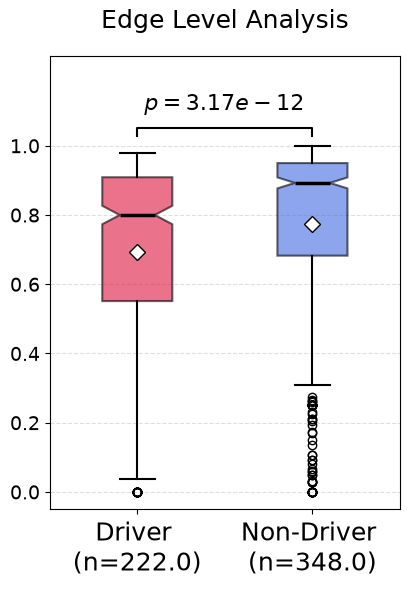

In [6]:
# 1. Separate the groups
drivers = df_actionability_all[df_actionability_all['driver_node'] == 'driver']['edge_actionability']
non_drivers = df_actionability_all[df_actionability_all['driver_node'] == 'non-driver']['edge_actionability']

# 2. Compute Statistics
# We use Mann-Whitney U as it's robust for biological viability data
u_stat, p_val_u = stats.mannwhitneyu(drivers, non_drivers, alternative='two-sided')

# 3. Set up the figure
plt.figure(figsize=(4.2, 6))

# 4. Create the labels with Sample Sizes (n=)
n_drivers = len(drivers) / 2
n_non_drivers = len(non_drivers) / 2
labels = [f'Driver \n(n={n_drivers})', f'Non-Driver \n(n={n_non_drivers})']

# 5. Plotting
data_to_plot = [drivers, non_drivers]
#bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True, widths=0.4)

bp = plt.boxplot(
    data_to_plot,
    tick_labels=labels,
    patch_artist=True,
    notch=True,
    widths=0.4,
    showmeans=True,
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='D',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8
    ),
    boxprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

# 6. Aesthetics
colors = ['crimson', 'royalblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 7. Add the Statistics (U-stat and P-Value) to the plot
y_max = max(df_actionability_all['edge_actionability'])
y_pos = y_max * 1.05 

# Format strings
# Using integer for u_stat as it is a count of rank sums
#u_text = f'$U = {u_stat:,.0f}$' 
p_text = f'$p = {p_val_u:.2e}$' if p_val_u < 0.001 else f'$p = {p_val_u:.4f}$'

# Combine texts with a newline
# We place this at y_pos * 1.02 to ensure the bracket doesn't overlap the text
#stats_label = f"{u_text}\n{p_text}"
stats_label = f"{(p_text)}"

# Draw the line
plt.plot([1, 1, 2, 2], [y_pos*0.98, y_pos, y_pos, y_pos*0.98], lw=1.5, c='black')

# Place the text
plt.text(1.5, y_pos * 1.02, stats_label, ha='center', va='bottom', 
         fontsize=16, fontweight='bold', linespacing=1.5)

# Adjust y-limit to ensure the double-line text isn't cut off
plt.ylim(0, y_pos * 1.25)

# --- MODIFICATIONS START HERE ---

# 1. Set Y-limit with a negative margin (e.g., -0.05) to add space under 0
# The top remains high enough to fit the stats
plt.ylim(-0.05, y_pos * 1.2)

# 2. Explicitly set Y-ticks to stop at 1.0
# This prevents 1.2 or other high numbers from appearing on the axis
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)

# 8. Labels and Title
plt.title('Edge Level Analysis', fontsize=18, pad=20)
#plt.ylabel('Actionability', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=18)

# 9. Save and Show
plt.tight_layout()
#plt.savefig('edge_actionability_with_stats.png', dpi=400)
plt.show()

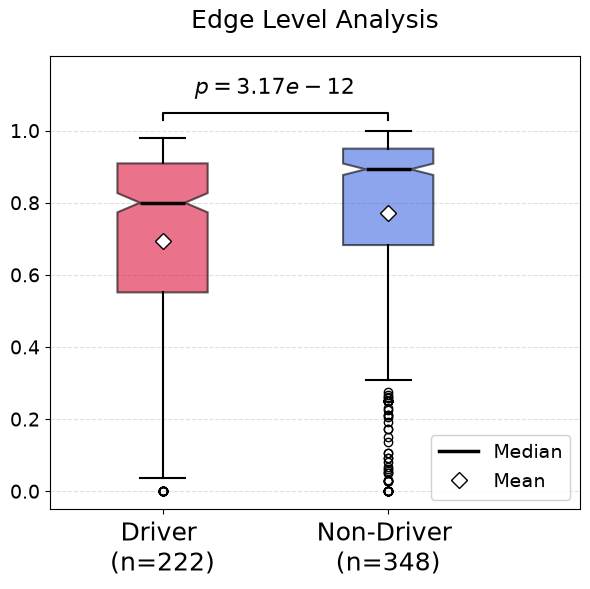

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

# 1. Separate the groups
drivers = df_actionability_all[df_actionability_all['driver_node'] == 'driver']['edge_actionability']
non_drivers = df_actionability_all[df_actionability_all['driver_node'] == 'non-driver']['edge_actionability']

# 2. Compute Statistics
u_stat, p_val_u = stats.mannwhitneyu(drivers, non_drivers, alternative='two-sided')

# 3. Set up the figure (Wider canvas)
plt.figure(figsize=(6, 6))

# 4. Create the labels with Sample Sizes (n=)
n_drivers = int(len(drivers) / 2)
n_non_drivers = int(len(non_drivers) / 2)
labels = [f'Driver \n(n={n_drivers})', f'Non-Driver \n(n={n_non_drivers})']

# 5. Plotting
data_to_plot = [drivers, non_drivers]

bp = plt.boxplot(
    data_to_plot,
    tick_labels=labels,
    patch_artist=True,
    notch=True,
    widths=0.4,
    showmeans=True,
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='D',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8
    ),
    boxprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

# 6. Aesthetics
colors = ['crimson', 'royalblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 7. Add Statistics
y_max = max(max(drivers), max(non_drivers)) 
y_pos = y_max * 1.05 

p_text = f'$p = {p_val_u:.2e}$' if p_val_u < 0.001 else f'$p = {p_val_u:.4f}$'

plt.plot([1, 1, 2, 2], [y_pos*0.98, y_pos, y_pos, y_pos*0.98], lw=1.5, c='black')
plt.text(1.5, y_pos * 1.02, p_text, ha='center', va='bottom', 
         fontsize=16, fontweight='bold', linespacing=1.5)

# Axis limits and ticks
plt.ylim(-0.05, y_pos * 1.15)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)

# Expand X-limit slightly to give the legend room on the right inside the plot
plt.xlim(0.5, 2.85)

# 8. Labels and Title
plt.title('Edge Level Analysis', fontsize=18, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=18)

# 9. Legend INSIDE plot (Bottom Right)
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, label='Median'),
    Line2D([0], [0], marker='D', color='w', label='Mean',
           markerfacecolor='white', markeredgecolor='black', markersize=8)
]

plt.legend(
    handles=legend_elements, 
    loc='lower right', 
    frameon=True, 
    facecolor='white', 
    framealpha=0.9, 
    fontsize=14
)

# 10. Save and Show
plt.tight_layout()
plt.show()

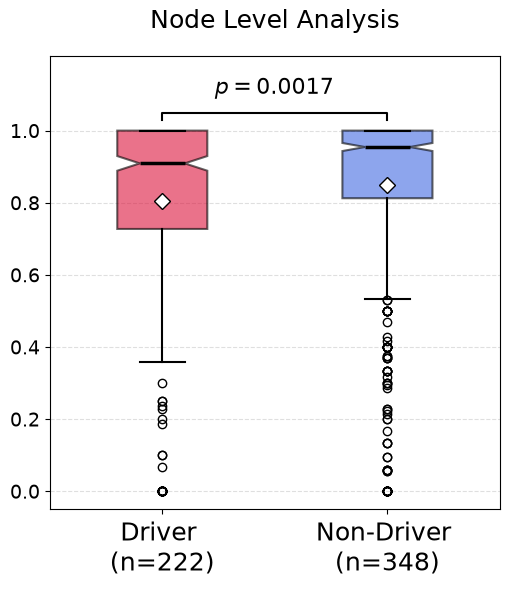

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

# 1. Separate the groups
drivers = df_actionability_all[df_actionability_all['driver_node'] == 'driver']['node_actionability']
non_drivers = df_actionability_all[df_actionability_all['driver_node'] == 'non-driver']['node_actionability']

# 2. Compute Statistics
u_stat, p_val_u = stats.mannwhitneyu(drivers, non_drivers, alternative='two-sided')

# 3. Figure size scaled down so the box plot dimensions stay identical
plt.figure(figsize=(5.2, 6))

# 4. Sample sizes & Labels
n_drivers = int(len(drivers) / 2)
n_non_drivers = int(len(non_drivers) / 2)
labels = [f'Driver \n(n={n_drivers})', f'Non-Driver \n(n={n_non_drivers})']

# 5. Plotting
data_to_plot = [drivers, non_drivers]

bp = plt.boxplot(
    data_to_plot,
    tick_labels=labels,
    patch_artist=True,
    notch=True,
    widths=0.4,
    showmeans=True,
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='D',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8
    ),
    boxprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

# 6. Aesthetics
colors = ['crimson', 'royalblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 7. Add Statistics
y_max = max(df_actionability_all['node_actionability'])
y_pos = y_max * 1.05 

p_text = f'$p = {p_val_u:.2e}$' if p_val_u < 0.001 else f'$p = {p_val_u:.4f}$'

plt.plot([1, 1, 2, 2], [y_pos*0.98, y_pos, y_pos, y_pos*0.98], lw=1.5, c='black')
plt.text(1.5, y_pos * 1.02, p_text, ha='center', va='bottom', 
         fontsize=16, fontweight='bold', linespacing=1.5)

# Axis limits and ticks
plt.ylim(-0.05, y_pos * 1.15)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)

# Standard symmetrical padding around positions 1 and 2
plt.xlim(0.5, 2.5)

# 8. Labels and Title
plt.title('Node Level Analysis', fontsize=18, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=18)

# 9. Save and Show
plt.tight_layout()
plt.show()

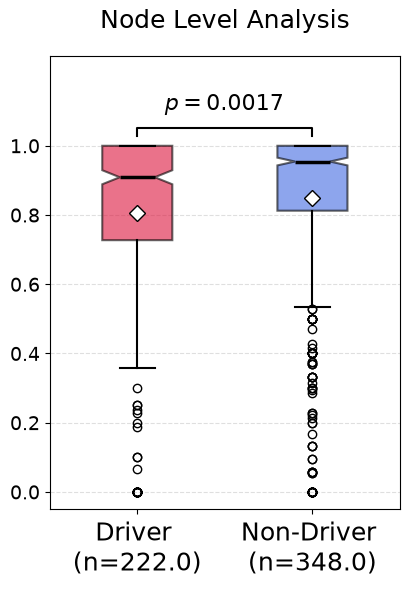

In [7]:
# 1. Separate the groups
drivers = df_actionability_all[df_actionability_all['driver_node'] == 'driver']['node_actionability']
non_drivers = df_actionability_all[df_actionability_all['driver_node'] == 'non-driver']['node_actionability']

# 2. Compute Statistics
# We use Mann-Whitney U as it's robust for biological viability data
u_stat, p_val_u = stats.mannwhitneyu(drivers, non_drivers, alternative='two-sided')

# 3. Set up the figure
plt.figure(figsize=(4.2, 6))

# 4. Create the labels with Sample Sizes (n=)
n_drivers = len(drivers) / 2
n_non_drivers = len(non_drivers) / 2
labels = [f'Driver \n(n={n_drivers})', f'Non-Driver \n(n={n_non_drivers})']

# 5. Plotting
data_to_plot = [drivers, non_drivers]
#bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True, widths=0.4)

bp = plt.boxplot(
    data_to_plot,
    tick_labels=labels,
    patch_artist=True,
    notch=True,
    widths=0.4,
    showmeans=True,
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='D',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=8
    ),
    boxprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

# 6. Aesthetics
colors = ['crimson', 'royalblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 7. Add the Statistics (U-stat and P-Value) to the plot
y_max = max(df_actionability_all['node_actionability'])
y_pos = y_max * 1.05 

# Format strings
# Using integer for u_stat as it is a count of rank sums
#u_text = f'$U = {u_stat:,.0f}$' 
p_text = f'$p = {p_val_u:.2e}$' if p_val_u < 0.001 else f'$p = {p_val_u:.4f}$'

# Combine texts with a newline
# We place this at y_pos * 1.02 to ensure the bracket doesn't overlap the text
#stats_label = f"{u_text}\n{p_text}"
stats_label = f"{(p_text)}"

# Draw the line
plt.plot([1, 1, 2, 2], [y_pos*0.98, y_pos, y_pos, y_pos*0.98], lw=1.5, c='black')

# Place the text
plt.text(1.5, y_pos * 1.02, stats_label, ha='center', va='bottom', 
         fontsize=16, fontweight='bold', linespacing=1.5)

# Adjust y-limit to ensure the double-line text isn't cut off
plt.ylim(0, y_pos * 1.25)

# --- MODIFICATIONS START HERE ---

# 1. Set Y-limit with a negative margin (e.g., -0.05) to add space under 0
# The top remains high enough to fit the stats
plt.ylim(-0.05, y_pos * 1.2)

# 2. Explicitly set Y-ticks to stop at 1.0
# This prevents 1.2 or other high numbers from appearing on the axis
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)

# 8. Labels and Title
plt.title('Node Level Analysis', fontsize=18, pad=20)
#plt.ylabel('Actionability', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=18)

# 9. Save and Show
plt.tight_layout()
#plt.savefig('edge_actionability_with_stats.png', dpi=400)
plt.show()

In [2]:
sModel = 'Cortical Area Development'
input_cnet = './datasets/targets/' + sModel + '.txt'
bn = BN.from_file(input_cnet, type='cnet')
perturbation_driver=[0,2,4]
input_node=[]
df_summary, df_combined = node_actionabulity_per_node(bn, perturbation_driver, input_node, False)

In [3]:
df_summary

,node_id,node_name,driver_node,node_role,IG_nodes,condition_state,N_ON,N_OFF,actionability
0,0,Emx2,driver,inner node,5,0,0,0,1.00
1,0,Emx2,driver,inner node,5,1,1,3,0.00
2,1,Pax6,non-driver,inner node,5,0,0,0,1.00
3,1,Pax6,non-driver,inner node,5,1,0,1,0.75
4,2,Fgf8,driver,inner node,5,0,2,2,0.00
5,2,Fgf8,driver,inner node,5,1,2,2,0.00
6,3,Coup_fti,non-driver,inner node,5,0,0,1,0.75
7,3,Coup_fti,non-driver,inner node,5,1,0,1,0.75
8,4,Sp8,driver,inner node,5,0,2,2,0.00
9,4,Sp8,driver,inner node,5,1,1,2,0.25
